# 3장 1강 프로젝트 개요와 문제 정의

## 실습 목표

- Ravenstack의 5개 테이블을 탐색하고 분석 단위와 연결 키를 설명한다.
- 데이터 품질과 기초 분포를 확인하여 분석 가능한 근거를 만든다.
- EDA 결과를 바탕으로 측정 가능한 문제, 목표 지표, 초기 가설을 정의한다.
- 이후 강의에서 검증할 분석 흐름을 일관되게 설계한다.

## 실습 환경 / 데이터

- Python / Colab, `pandas`, `matplotlib`
- `ravenstack_accounts.csv`: 계정 속성과 계정 이탈 여부
- `ravenstack_subscriptions.csv`: 구독 이력과 MRR, 플랜, 이탈 여부
- `ravenstack_feature_usage.csv`: 기능별 사용량과 오류
- `ravenstack_support_tickets.csv`: 문의 처리와 만족도
- `ravenstack_churn_events.csv`: 이탈 사유와 환불

> 분석 기준: 계정의 대표 이탈 지표는 `accounts.churn_flag`로 정의합니다. 서로 다른 테이블의 같은 이름 컬럼을 임의로 섞지 않습니다.

## 실습 준비

### 데이터 불러오기

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

file_names = {
    "accounts": "ravenstack_accounts.csv",
    "subscriptions": "ravenstack_subscriptions.csv",
    "feature_usage": "ravenstack_feature_usage.csv",
    "support_tickets": "ravenstack_support_tickets.csv",
    "churn_events": "ravenstack_churn_events.csv",
}

candidate_dirs = [Path("."), Path("upload"), Path("/content")]
data_dir = next((d for d in candidate_dirs if all((d / f).exists() for f in file_names.values())), None)
if data_dir is None:
    raise FileNotFoundError("5개 CSV를 노트북과 같은 폴더(또는 /content)에 업로드해 주세요.")

data = {name: pd.read_csv(data_dir / file) for name, file in file_names.items()}
accounts = data["accounts"]
subscriptions = data["subscriptions"]
feature_usage = data["feature_usage"]
support_tickets = data["support_tickets"]
churn_events = data["churn_events"]

print("데이터 폴더:", data_dir.resolve())
for name, df in data.items():
    print(f"{name:16s}: {df.shape[0]:,}행 × {df.shape[1]}열")

데이터 폴더: C:\first-project\product
accounts        : 500행 × 10열
subscriptions   : 5,000행 × 14열
feature_usage   : 25,000행 × 8열
support_tickets : 2,000행 × 9열
churn_events    : 600행 × 9열


### 분석 대상 컬럼 확인

각 테이블의 앞부분과 컬럼을 확인하세요.

In [2]:
for name, df in data.items():
    print(f"\n[{name}] 컬럼")
    print(df.columns.tolist())
    display(df.head(2))


[accounts] 컬럼
['account_id', 'account_name', 'industry', 'country', 'signup_date', 'referral_source', 'plan_tier', 'seats', 'is_trial', 'churn_flag']


,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True



[subscriptions] 컬럼
['subscription_id', 'account_id', 'start_date', 'end_date', 'plan_tier', 'seats', 'mrr_amount', 'arr_amount', 'is_trial', 'upgrade_flag', 'downgrade_flag', 'churn_flag', 'billing_frequency', 'auto_renew_flag']


,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True



[feature_usage] 컬럼
['usage_id', 'subscription_id', 'usage_date', 'feature_name', 'usage_count', 'usage_duration_secs', 'error_count', 'is_beta_feature']


,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False



[support_tickets] 컬럼
['ticket_id', 'account_id', 'submitted_at', 'closed_at', 'resolution_time_hours', 'priority', 'first_response_time_minutes', 'satisfaction_score', 'escalation_flag']


,ticket_id,account_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag
0,T-0024de,A-712f1c,2023-07-27,2023-07-28 03:00:00,27.0,high,74,NaN,False
1,T-4d04b9,A-e43bf7,2024-07-08,2024-07-09 03:00:00,27.0,urgent,144,NaN,False



[churn_events] 컬럼
['churn_event_id', 'account_id', 'churn_date', 'reason_code', 'refund_amount_usd', 'preceding_upgrade_flag', 'preceding_downgrade_flag', 'is_reactivation', 'feedback_text']


,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
0,C-816288,A-c37cab,2024-10-27,pricing,4.03,False,False,False,switched to competitor
1,C-5a81e7,A-37f969,2024-06-25,support,96.45,True,False,False,NaN


### 결측치 및 자료형 확인

날짜 컬럼을 변환하고 키 중복을 확인합니다.

In [3]:
# 날짜 컬럼을 datetime으로 변환합니다.
date_columns = {
    "accounts": ["signup_date"],
    "subscriptions": ["start_date", "end_date"],
    "feature_usage": ["usage_date"],
    "support_tickets": ["submitted_at", "closed_at"],
    "churn_events": ["churn_date"],
}
for name, columns in date_columns.items():
    for column in columns:
        data[name][column] = pd.to_datetime(data[name][column], errors="coerce")

# 분석 단위와 키를 확인합니다.
key_columns = {
    "accounts": "account_id",
    "subscriptions": "subscription_id",
    "feature_usage": "usage_id",
    "support_tickets": "ticket_id",
    "churn_events": "churn_event_id",
}
for name, key in key_columns.items():
    df = data[name]
    print(f"{name:16s} | key 중복 {df[key].duplicated().sum():>2} | 전체 행 중복 {df.duplicated().sum():>2}")

accounts         | key 중복  0 | 전체 행 중복  0
subscriptions    | key 중복  0 | 전체 행 중복  0
feature_usage    | key 중복 21 | 전체 행 중복  0
support_tickets  | key 중복  0 | 전체 행 중복  0
churn_events     | key 중복  0 | 전체 행 중복  0


### 기초 통계량과 분포 확인

아래 코드로 수치형 변수와 주요 범주의 분포를 확인하세요.

In [4]:
display(accounts[["seats", "churn_flag"]].describe())
display(accounts["plan_tier"].value_counts().rename("accounts"))
display(churn_events["reason_code"].value_counts().rename("events"))

#max수치 이상함 확인 필요

,seats
count,500.000000
mean,20.560000
std,21.044718
min,1.000000
25%,5.000000
50%,15.000000
75%,28.000000
max,163.000000


plan_tier
Pro           178
Basic         168
Enterprise    154
Name: accounts, dtype: int64

reason_code
features      114
support       104
budget        104
unknown        95
competitor     92
pricing        91
Name: events, dtype: int64

---

## 필수 1 — 5개 테이블의 EDA 요약

각 테이블에 대해 다음 항목을 하나의 요약표로 만드세요.

1. 행 수와 열 수
2. 전체 결측치 수
3. 완전히 동일한 중복 행 수
4. 날짜 범위(최솟값~최댓값)

그 후 다음 질문에 답하세요.

- 결측치가 있는 테이블과 컬럼은 무엇인가요?  
-> subscriptions: end_date(4,514건), support_tickets: satisfaction_score(825건), churn_events: feedback_text(148건)  
- 결측치를 곧바로 삭제하면 안 되는 이유는 무엇인가요?  
-> 컬럼마다 결측치가 나타내는 의미가 다르기 때문에 삭제하면 특정 상황(응답하지 않은 고객, 사유를 안 남긴 이탈)이  
체계적으로 분석에서 빠지는 편향이 생길 수 있음.
- 분석 전에 주의할 데이터 품질 문제를 한 가지 쓰세요.  
-> feature_usage의 usage_id에 21건의 중복행이 있음  
usage_id 컬럼을 기준으로 groupby나 join을 하면 의도치 않게 행이 늘어나거나 집계가 왜곡될 수 있어 사용 전에 확인이 필요.


In [5]:
# TODO: 테이블별 EDA 요약표를 만드세요.
summary_rows = []

# 여기에 코드를 작성하세요.

eda_summary = pd.DataFrame(summary_rows)
display(eda_summary)

# 테이블별 대표 날짜 컬럼 (그 행이 '언제 발생했는지'를 나타내는 컬럼)
main_date_columns = {
    "accounts": "signup_date",
    "subscriptions": "start_date",
    "feature_usage": "usage_date",
    "support_tickets": "submitted_at",
    "churn_events": "churn_date",
}

summary_rows = []
for name, df in data.items():
    date_col = main_date_columns[name]
    summary_rows.append({
        "table": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "missing_total": int(df.isna().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum()),
        "date_column": date_col,
        "date_min": df[date_col].min().date(),
        "date_max": df[date_col].max().date(),
    })

eda_summary = pd.DataFrame(summary_rows)
display(eda_summary)

# 결측치 확인 컬럼 코드
for name, df in data.items():
    missing = df.isna().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f"\n[{name}]")
        print(missing.to_string())

""


,table,rows,columns,missing_total,duplicate_rows,date_column,date_min,date_max
0,accounts,500,10,0,0,signup_date,2023-01-02,2024-12-31
1,subscriptions,5000,14,4514,0,start_date,2023-01-09,2024-12-31
2,feature_usage,25000,8,0,0,usage_date,2023-01-01,2024-12-31
3,support_tickets,2000,9,825,0,submitted_at,2023-01-02,2024-12-31
4,churn_events,600,9,148,0,churn_date,2023-01-25,2024-12-31



[subscriptions]
end_date    4514

[support_tickets]
satisfaction_score    825

[churn_events]
feedback_text    148


---

## 필수 2 — 근거를 연결해 분석 문제 정의하기

계정 테이블을 기준으로 다음을 분석하세요.

1. 전체 계정 이탈률을 계산하세요.
2. `industry`, `referral_source`, `is_trial`별 계정 수와 이탈률을 계산하세요.
3. 표본이 20개 이상인 세그먼트 중 전체 이탈률보다 높은 구간을 찾으세요.
4. 결과를 근거로 **문제 정의 1문장**, **현재 지표**, **목표 지표**를 작성하세요.
5. 이탈률이 가장 높은 산업군을 막대그래프로 비교하세요.

> 목표값은 정답이 하나가 아닙니다. 현재 값보다 개선된 수치이며, 지표·대상·기간(또는 평가 시점)이 드러나게 작성하세요.

전체 계정 이탈률: 22.0%

[industry]


,account_count,churn_rate,churn_rate_pct
industry,,,
DevTools,113,0.309735,31.0
FinTech,112,0.223214,22.3
HealthTech,96,0.218750,21.9
EdTech,79,0.164557,16.5
Cybersecurity,100,0.160000,16.0



[referral_source]


,account_count,churn_rate,churn_rate_pct
referral_source,,,
event,96,0.302083,30.2
other,103,0.242718,24.3
ads,98,0.234694,23.5
organic,114,0.175439,17.5
partner,89,0.146067,14.6



[is_trial]


,account_count,churn_rate,churn_rate_pct
is_trial,,,
True,97,0.257732,25.8
False,403,0.210918,21.1



=== 표본 20개 이상 & 전체 이탈률보다 높은 세그먼트 ===


,column,segment,account_count,churn_rate_pct
0,industry,DevTools,113,31.0
1,referral_source,event,96,30.2
2,is_trial,True,97,25.8
3,referral_source,other,103,24.3
4,referral_source,ads,98,23.5
5,industry,FinTech,112,22.3


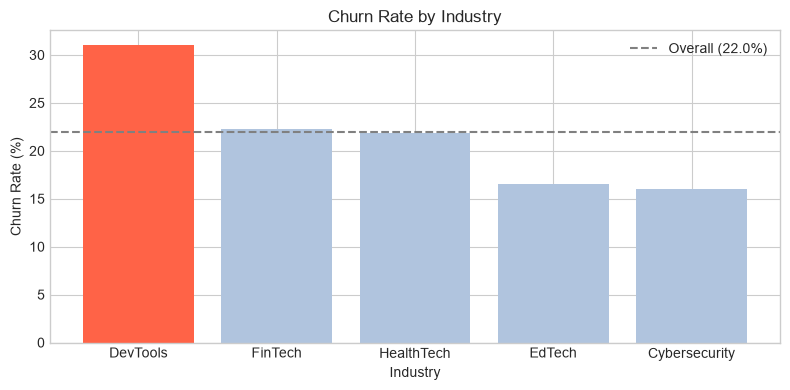


이탈률이 가장 높은 산업군: DevTools (31.0%)


In [7]:
# TODO: 전체 및 세그먼트별 이탈률을 계산하세요.
overall_churn_rate = ...

segment_results = {}
for column in ["industry", "referral_source", "is_trial"]:
    # 여기에 코드를 작성하세요.
    pass

# TODO: 산업별 이탈률 그래프를 그리세요.

import matplotlib.pyplot as plt

# ===== 1. 전체 계정 이탈률 =====
overall_churn_rate = accounts["churn_flag"].mean()
print(f"전체 계정 이탈률: {overall_churn_rate*100:.1f}%")

# ===== 2. 세그먼트별 계정 수와 이탈률 =====
segment_results = {}
for column in ["industry", "referral_source", "is_trial"]:
    seg = (
        accounts.groupby(column)
        .agg(account_count=("account_id", "nunique"), churn_rate=("churn_flag", "mean"))
        .sort_values("churn_rate", ascending=False)
    )
    seg["churn_rate_pct"] = (seg["churn_rate"] * 100).round(1)
    segment_results[column] = seg
    print(f"\n[{column}]")
    display(seg)

# ===== 3. 표본 20개 이상 + 전체 이탈률보다 높은 세그먼트 =====
high_rows = []
for column, seg in segment_results.items():
    hit = seg[(seg["account_count"] >= 20) & (seg["churn_rate"] > overall_churn_rate)]
    for idx, row in hit.iterrows():
        high_rows.append({
            "column": column,
            "segment": idx,
            "account_count": int(row["account_count"]),
            "churn_rate_pct": row["churn_rate_pct"],
        })

high_segment_df = (
    pd.DataFrame(high_rows)
    .sort_values("churn_rate_pct", ascending=False)
    .reset_index(drop=True)
)
print("\n=== 표본 20개 이상 & 전체 이탈률보다 높은 세그먼트 ===")
display(high_segment_df)

# ===== 5. 산업별 이탈률 막대그래프 =====
industry_churn = segment_results["industry"]
colors = ["tomato"] + ["lightsteelblue"] * (len(industry_churn) - 1)

plt.figure(figsize=(8, 4))
plt.bar(industry_churn.index, industry_churn["churn_rate_pct"], color=colors)
plt.axhline(
    overall_churn_rate * 100,
    color="gray",
    linestyle="--",
    label=f"Overall ({overall_churn_rate*100:.1f}%)",
)
plt.title("Churn Rate by Industry")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Industry")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n이탈률이 가장 높은 산업군: {industry_churn.index[0]} ({industry_churn['churn_rate_pct'].iloc[0]}%)")

### 필수 2 서술 답안

| 세그먼트 | 이탈률 | 근거 | 해석 |
|---|---|---|---|
| DevTools (industry) | 31.0% | 계정 113개 중 35개가 이탈로 표시 | 이탈 비중이 높은 산업집단이므로 후속 분석의 우선 대상으로 삼을 수 있음 |
| event (referral_source) | 30.2% | 유입 경로가 event인 계정 96개 중 29개가 이탈로 표시됨 | 이 유입 경로의 고객 구성과 이후 이용 경험을 추가로 살펴볼 필요가 있음 |
| 체험 / 비체험 (is_trial) | 체험 25.8% / 비체험 21.1% | 각각 97개 중 25개, 403개 중 85개가 이탈로 표시됨 | 체험 집단의 이탈 비중이 약 4.7%p 높지만, 체험 제공이 이탈을 유발했다고 결론 내릴 수는 없음 |

- 발견한 핵심 패턴: 산업 집단 중 devtools가 가장이탈률이 높았다 
- 문제 정의: 이탈 어떻게 줄일 수 있는지 원인분석한다  
- 현재 지표: 이탈률로 잡았기 때문에 이탈률을 KPI로 지표 선택
- 목표 지표: 31%를 22%까지 줄이는 것
- 목표 지표가 적절한 이유: 산업군 중 가장 시급하게 해결해야하기 때문

---

## 과제 1 — 이탈 원인 가설과 검증 계획 세우기

필수 2에서 정의한 문제를 바탕으로 초기 가설 3개를 작성하세요.

- 적어도 2개는 현재 제공된 데이터로 검증 가능해야 합니다.
- 각 가설에 `필요한 테이블·컬럼`, `확인할 비교 또는 지표`, `우선순위`를 적으세요.
- 가장 먼저 검증할 가설 1개를 고르고 이유를 설명하세요.
- 2강 분석 → 3강 실험 → 4강 제안이 처음 문제와 어떻게 연결되는지 한 문장씩 작성하세요.

| 우선순위 | 가설 | 필요한 데이터 | 검증 방법 |
|---:|---|---|---|
| 1 | DevTools 계정은 특정 기능에서 에러가 자주 나서 이탈했을 것 | feature_usage(subscription_id, error_count, feature_name), subscriptions(account_id), accounts(industry, churn_flag) | DevTools을 이탈, 비이탈로 나누어 평균 error_count 또는 error 발생 비율을 비교 |
| 2 | DevTools 계정은 고객지원 응답이 느리거나 만족도가 낮아 이탈했을 것 | support_tickets(account_id, resolution_time_hours, first_response_time_minutes, satisfaction_score), accounts(industry, churn_flag) | DevTools 계정을 이탈, 비이탈로 나누어 평균 resolution_time_hours·first_response_time_minutes·satisfaction_score등을 비교 |
| 3 | DevTools 계정은 경쟁사로 이동해 이탈했을 것 | churn_events(account_id, reason_code), accounts(industry) | DevTools 이탈 계정 중 reason_code가 'competitor'인 비중을 다른 산업군과 비교 |

**답안 작성**

**가장 먼저 검증할 가설**: 가설 1  
**이유**: churn_events의 이탈 사유 중 'features'가 114건으로 가장 많고, feature_usage에 25,000행 정도 사용 기록이 있어  
어떤 기능에서 오류가 났는지까지 확인할 수 있음.

- 2강 분석: DevTools 계정의 기능 오류, 고객지원 지표, 이탈 사유를 이탈,비이탈 계정으로 나누어 비교하고 이탈과 연관된 요인을 확인
- 3강 실험: 분석에서 확인된 요인(오류가 잦은 기능 등)을 개선하여, DevTools 계정의 이탈률이 실제로 낮아지는지 검증.
- 4강 제안: 실험에서 효과가 확인된 개선안을 바탕으로, DevTools 계정 이탈률을 31.0%에서 22.0%로 낮추기 위한 방안을 제안.

---

## 실습 마무리

- 어떤 분석 문제가 있었는가?  
-> DevTools 산업, 다른 산업군에 비해 이탈률이 높다.  

- 어떤 통계적·분석적 방법을 적용했는가?  
-> 데이터 전처리, EDA

- 무엇을 근거로 결론을 내렸는가?  
-> 전체 이탈율 22.0%와 DevTools 이탈율 31.0% 정도, event 유입 30.2%, 체험 계정 25.8%를 기준으로 결론을 내렸다.
